In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [5]:
# Load CSV file
df = pd.read_csv("/content/energy_data.csv")

# Display first 5 rows
df.head()

,timestamp,location,energy_consumption,temperature
0,01-01-2023 00:00,Industrial,139.101364,33.820542
1,01-01-2023 01:00,Residential,247.109808,26.392602
2,01-01-2023 02:00,Industrial,233.934693,25.027439
3,01-01-2023 03:00,Industrial,243.013532,27.107712
4,01-01-2023 04:00,Residential,313.502582,27.326153


In [6]:
# Dataset Information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp           10000 non-null  object 
 1   location            10000 non-null  object 
 2   energy_consumption  10000 non-null  float64
 3   temperature         10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 312.6+ KB
None


In [7]:
# Check Shape
print("Rows and Columns:", df.shape)

Rows and Columns: (10000, 4)


In [8]:
# Check Data Types
print(df.dtypes)

timestamp              object
location               object
energy_consumption    float64
temperature           float64
dtype: object


In [9]:
# Check Missing Values
print(df.isnull().sum())

timestamp             0
location              0
energy_consumption    0
temperature           0
dtype: int64


In [10]:
# Remove Missing Values (If Any)
df = df.dropna()

print(df.isnull().sum())

timestamp             0
location              0
energy_consumption    0
temperature           0
dtype: int64


In [11]:
# Check Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [12]:
# Check Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [13]:
# Dataset Summary
print(df.describe())

       energy_consumption   temperature
count        10000.000000  10000.000000
mean           275.404802     24.991026
std            129.290724      5.783142
min             50.053390     15.000186
25%            165.525565     19.971860
50%            275.677604     24.963709
75%            385.844981     30.000277
max            499.951700     34.997821


In [14]:
# Unique Values
print(df["location"].unique())

['Industrial' 'Residential' 'Commercial']


In [15]:
# Convert Timestamp into DateTime
df["timestamp"] = pd.to_datetime(df["timestamp"], dayfirst=True)

df.head()

,timestamp,location,energy_consumption,temperature
0,2023-01-01 00:00:00,Industrial,139.101364,33.820542
1,2023-01-01 01:00:00,Residential,247.109808,26.392602
2,2023-01-01 02:00:00,Industrial,233.934693,25.027439
3,2023-01-01 03:00:00,Industrial,243.013532,27.107712
4,2023-01-01 04:00:00,Residential,313.502582,27.326153


In [16]:
# Feature Engineering
df["Hour"] = df["timestamp"].dt.hour
df["Day"] = df["timestamp"].dt.day
df["Month"] = df["timestamp"].dt.month

df.head()

,timestamp,location,energy_consumption,temperature,Hour,Day,Month
0,2023-01-01 00:00:00,Industrial,139.101364,33.820542,0,1,1
1,2023-01-01 01:00:00,Residential,247.109808,26.392602,1,1,1
2,2023-01-01 02:00:00,Industrial,233.934693,25.027439,2,1,1
3,2023-01-01 03:00:00,Industrial,243.013532,27.107712,3,1,1
4,2023-01-01 04:00:00,Residential,313.502582,27.326153,4,1,1


In [17]:
# Encode Location Column
encoder = LabelEncoder()

df["location_encoded"] = encoder.fit_transform(df["location"])

df.head()

,timestamp,location,energy_consumption,temperature,Hour,Day,Month,location_encoded
0,2023-01-01 00:00:00,Industrial,139.101364,33.820542,0,1,1,1
1,2023-01-01 01:00:00,Residential,247.109808,26.392602,1,1,1,2
2,2023-01-01 02:00:00,Industrial,233.934693,25.027439,2,1,1,1
3,2023-01-01 03:00:00,Industrial,243.013532,27.107712,3,1,1,1
4,2023-01-01 04:00:00,Residential,313.502582,27.326153,4,1,1,2


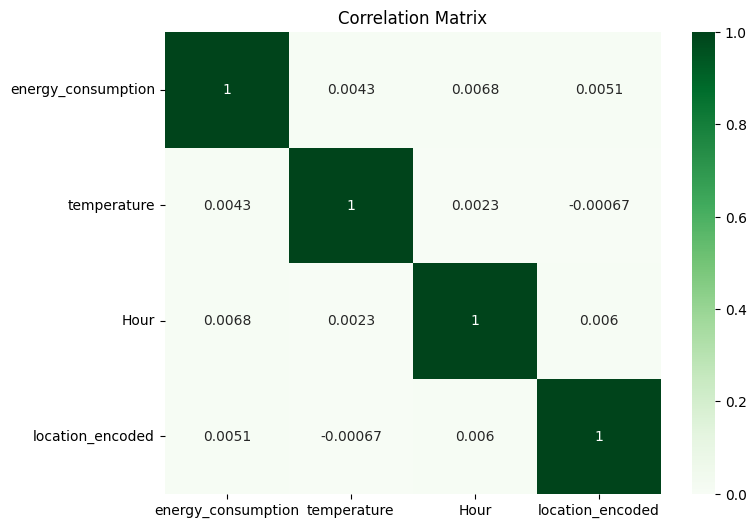

In [18]:
# Correlation Matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    df[["energy_consumption","temperature","Hour","location_encoded"]].corr(),
    annot=True,
    cmap="Greens"
)

plt.title("Correlation Matrix")
plt.show()

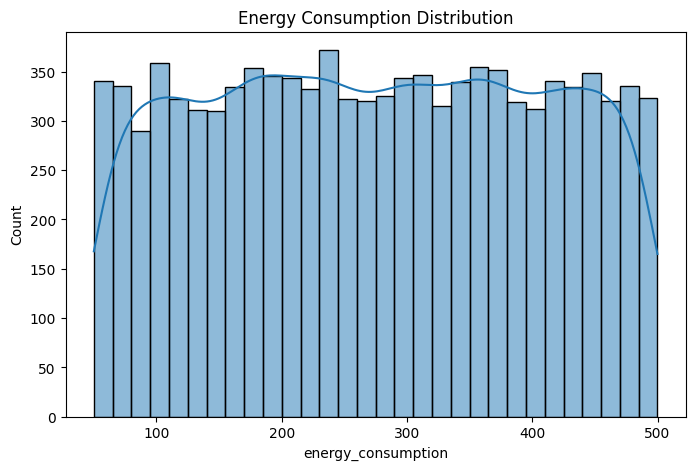

In [19]:
# Distribution of Energy Consumption
plt.figure(figsize=(8,5))

sns.histplot(df["energy_consumption"], bins=30, kde=True)

plt.title("Energy Consumption Distribution")
plt.show()

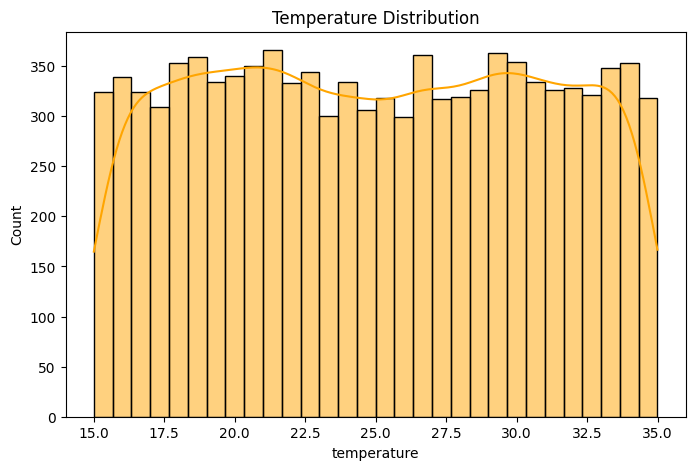

In [20]:
# Temperature Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["temperature"], bins=30, color="orange", kde=True)

plt.title("Temperature Distribution")
plt.show()

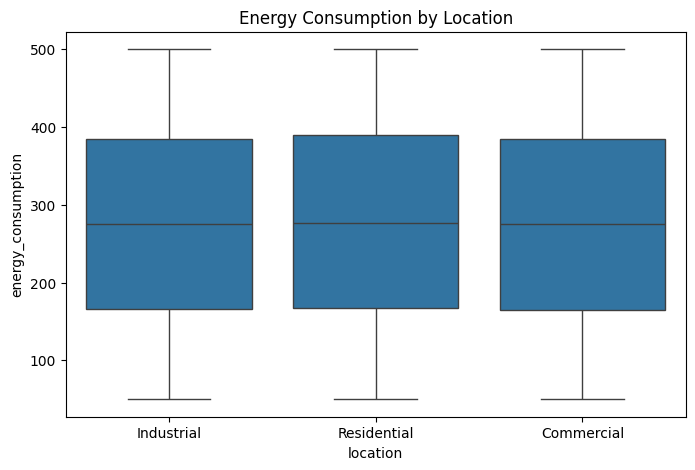

In [21]:
# Energy Consumption by Location
plt.figure(figsize=(8,5))

sns.boxplot(
    x="location",
    y="energy_consumption",
    data=df
)

plt.title("Energy Consumption by Location")
plt.show()

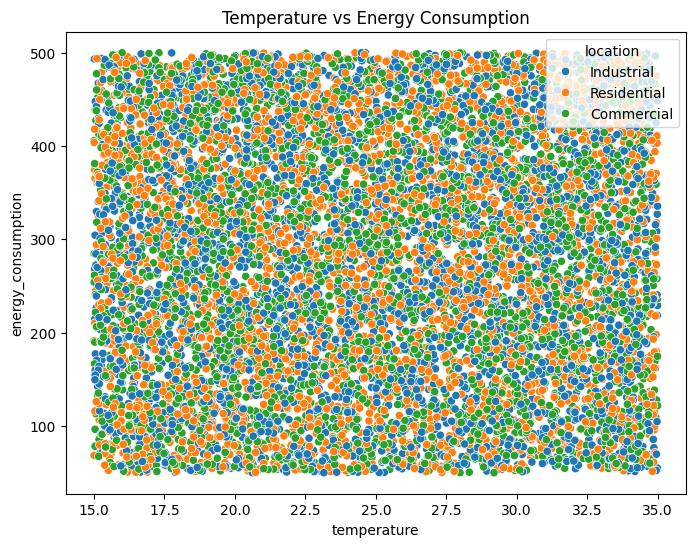

In [22]:
# Scatter Plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="temperature",
    y="energy_consumption",
    hue="location",
    data=df
)

plt.title("Temperature vs Energy Consumption")
plt.show()

In [23]:
# Prepare Features for K-Means
X = df[
    [
        "energy_consumption",
        "temperature",
        "Hour",
        "location_encoded"
    ]
]

In [24]:
# Standardize Data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

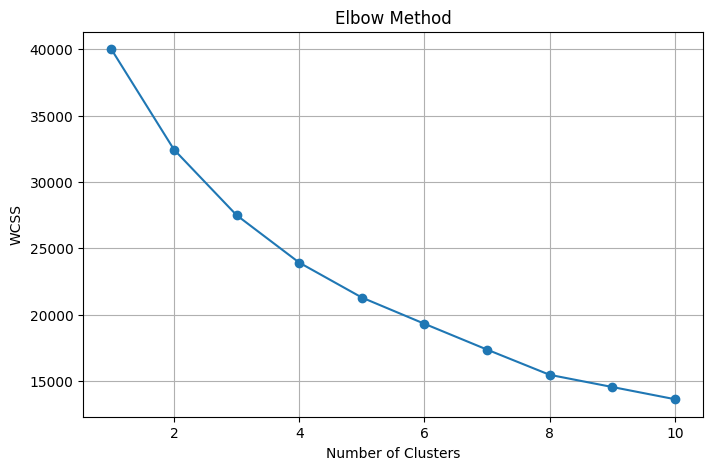

In [25]:
# Elbow Method
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.title("Elbow Method")
plt.grid()

plt.show()

In [26]:
# Apply K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

df.head()

,timestamp,location,energy_consumption,temperature,Hour,Day,Month,location_encoded,Cluster
0,2023-01-01 00:00:00,Industrial,139.101364,33.820542,0,1,1,1,1
1,2023-01-01 01:00:00,Residential,247.109808,26.392602,1,1,1,2,1
2,2023-01-01 02:00:00,Industrial,233.934693,25.027439,2,1,1,1,0
3,2023-01-01 03:00:00,Industrial,243.013532,27.107712,3,1,1,1,1
4,2023-01-01 04:00:00,Residential,313.502582,27.326153,4,1,1,2,1


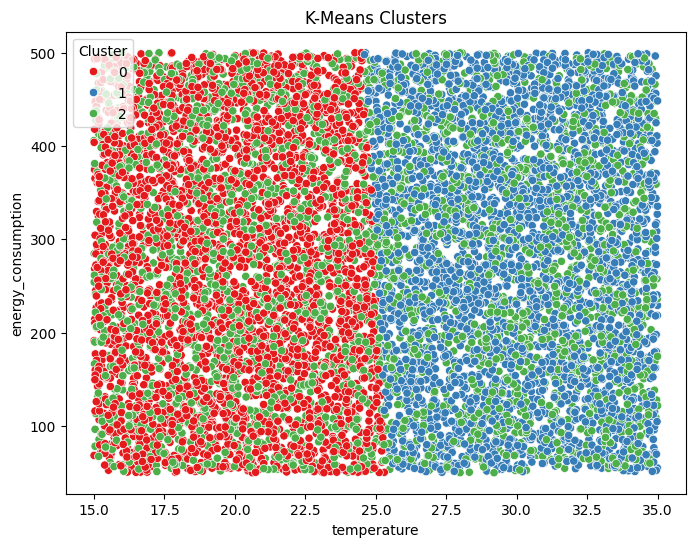

In [27]:
# Cluster Visualization
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="temperature",
    y="energy_consumption",
    hue="Cluster",
    palette="Set1",
    data=df
)

plt.title("K-Means Clusters")

plt.show()

In [28]:
# Cluster Count
print(df["Cluster"].value_counts())

Cluster
2    3347
1    3332
0    3321
Name: count, dtype: int64


In [29]:
# Cluster Centers
print(kmeans.cluster_centers_)

[[-3.35466130e-02 -8.64258244e-01  6.14093131e-03  6.15826904e-01]
 [ 3.95458224e-02  8.66227712e-01 -5.18406266e-05  6.14166761e-01]
 [-6.01706039e-03 -3.24997019e-03 -6.04717007e-03 -1.22245885e+00]]


In [30]:
# Evaluate Model
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score :", score)

Silhouette Score : 0.18680853358060417


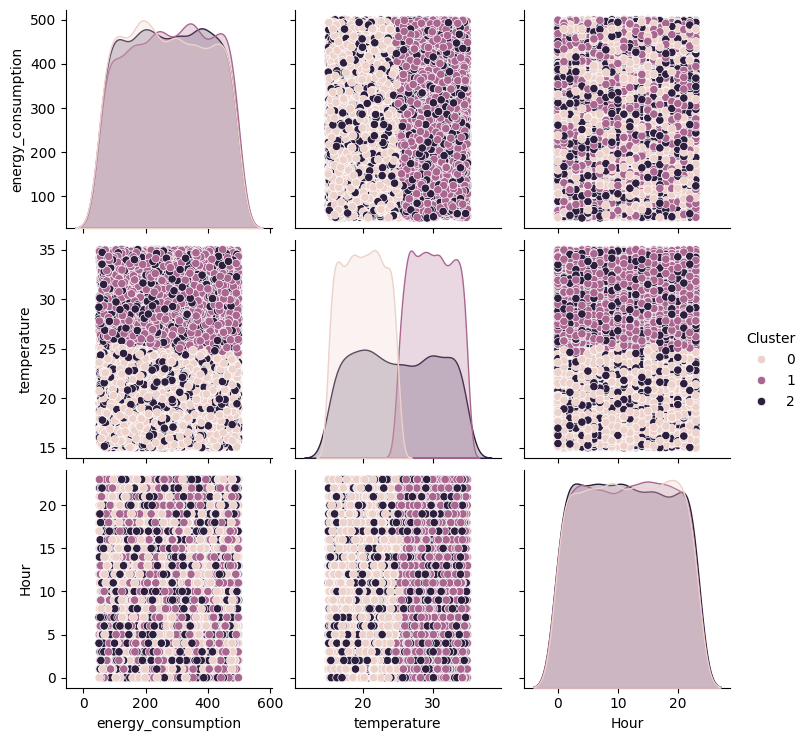

In [31]:
# Pair Plot
sns.pairplot(
    df,
    vars=[
        "energy_consumption",
        "temperature",
        "Hour"
    ],
    hue="Cluster"
)

plt.show()

In [32]:
# Final Dataset
df.head()

,timestamp,location,energy_consumption,temperature,Hour,Day,Month,location_encoded,Cluster
0,2023-01-01 00:00:00,Industrial,139.101364,33.820542,0,1,1,1,1
1,2023-01-01 01:00:00,Residential,247.109808,26.392602,1,1,1,2,1
2,2023-01-01 02:00:00,Industrial,233.934693,25.027439,2,1,1,1,0
3,2023-01-01 03:00:00,Industrial,243.013532,27.107712,3,1,1,1,1
4,2023-01-01 04:00:00,Residential,313.502582,27.326153,4,1,1,2,1


In [33]:
# Save Clustered Dataset
df.to_csv("energy_data_clustered.csv", index=False)

print("Clustered dataset saved successfully.")

Clustered dataset saved successfully.
